In [18]:
import pandas as pd
import numpy as np

In [19]:
# 1. Chargement du dataset (assure-toi d'avoir uploadé Matches.csv)
try :
  df = pd.read_csv('../data/Matches.csv')
except FileNotFoundError :
  print('Fichier Matches.csv non trouvé')

C:\Users\DPcomputer\AppData\Local\Temp\ipykernel_20400\2628787285.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/Matches.csv')


In [20]:
# 2. Conversion de la date en format datetime pour pouvoir filtrer
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

# 3. Filtrage : Premier League + Saisons récentes (depuis août 2019)
mask = (df['Division'] == 'E1') & (df['MatchDate'] >= '2019-08-01')
df_pl = df.loc[mask].copy()

# 4. Encodage de la cible
res_mapping = {'H': 2, 'D': 1, 'A': 0}
df_pl['Result_Code'] = df_pl['FTResult'].map(res_mapping)

# 5. Nettoyage rapide : on enlève les lignes où les stats de tirs sont manquantes
cols_vitales = ['HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget']
df_pl = df_pl.dropna(subset=cols_vitales)

print(f"Analyse prête sur {len(df_pl)} matchs de Premier League (2019-2025).")
print(f"Période : du {df_pl['MatchDate'].min().date()} au {df_pl['MatchDate'].max().date()}")

Analyse prête sur 3310 matchs de Premier League (2019-2025).
Période : du 2019-08-02 au 2025-05-03


In [21]:
# Création des variables explicatives (Différentiels)

# 1. Différentiel de niveau (Elo)
df_pl['Diff_Elo'] = df_pl['HomeElo'] - df_pl['AwayElo']

# 2. Différentiel d'efficacité offensive (Tirs cadrés)
df_pl['Diff_Target'] = df_pl['HomeTarget'] - df_pl['AwayTarget']

# 3. Différentiel de volume de jeu (Tirs totaux)
df_pl['Diff_Shots'] = df_pl['HomeShots'] - df_pl['AwayShots']

# 4. Différentiel de forme récente (sur 5 matchs)
df_pl['Diff_Form5'] = df_pl['Form5Home'] - df_pl['Form5Away']

# 5. Différentiel de discipline (Cartons Rouges)
# On s'attend à un coefficient négatif ici : plus on a de rouges, moins on gagne
df_pl['Diff_RedCards'] = df_pl['HomeRed'] - df_pl['AwayRed']

# 6. Différentiel de corners (Pression offensive)
df_pl['Diff_Corners'] = df_pl['HomeCorners'] - df_pl['AwayCorners']

# Sélection des colonnes pour notre matrice X (les causes)
X_cols = ['Diff_Elo', 'Diff_Target', 'Diff_Shots', 'Diff_Form5', 'Diff_RedCards', 'Diff_Corners']

print("Variables explicatives créées.")
display(df_pl[X_cols + ['Result_Code']].head())

Variables explicatives créées.


,Diff_Elo,Diff_Target,Diff_Shots,Diff_Form5,Diff_RedCards,Diff_Corners,Result_Code
162731,-128.78,-4.0,-5.0,-5.0,0.0,-3.0,1
162789,-171.04,0.0,2.0,3.0,0.0,2.0,2
162790,51.91,-3.0,5.0,-2.0,0.0,10.0,0
162791,44.50,2.0,14.0,3.0,0.0,4.0,0
162792,-63.79,3.0,3.0,-2.0,0.0,1.0,2


In [22]:
# Préparation et Standardisation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Nettoyage des NaN créés par les différentiels (ex: Forme manquante)
df_model = df_pl.dropna(subset=X_cols)
print(f"Matchs restants après nettoyage final : {len(df_model)}")

# 2. Définition de X (les causes) et y (le résultat)
X = df_model[X_cols]
y = df_model['Result_Code']

# 3. Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données prêtes et standardisées.")

Matchs restants après nettoyage final : 3308
Données prêtes et standardisées.


In [23]:
from sklearn.linear_model import LogisticRegression

# Entraînement du Modèle Explicatif (Multinomial)
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Modèle entraîné avec succès.")
print(f"Précision globale du modèle sur le test set : {model.score(X_test_scaled, y_test):.2%}")

Modèle entraîné avec succès.
Précision globale du modèle sur le test set : 57.85%


C:\Users\DPcomputer\AppData\Local\Temp\ipykernel_20400\1991547583.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Variable', data=importance_df, palette='viridis')


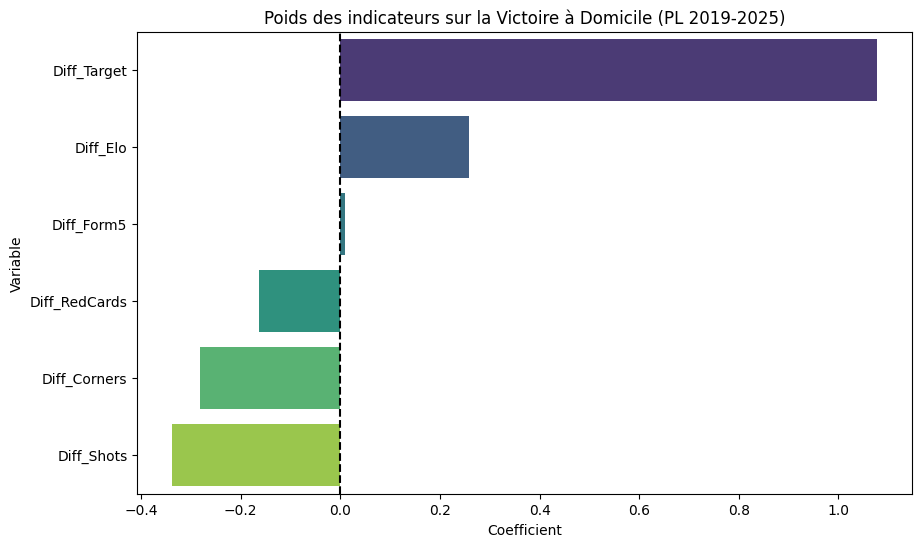

        Variable  Coefficient
1    Diff_Target     1.077196
0       Diff_Elo     0.258681
3     Diff_Form5     0.010383
4  Diff_RedCards    -0.162673
5   Diff_Corners    -0.281339
2     Diff_Shots    -0.337108


In [24]:
# Visualisation des Coefficients (Explication)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraction des coefficients pour la Victoire Domicile (Classe 2)
# Rappel : res_mapping = {'H': 2, 'D': 1, 'A': 0}
# L'index 2 correspond donc à la victoire à domicile
coefs = model.coef_[2]

# 2. Création d'un DataFrame pour la visualisation
importance_df = pd.DataFrame({
    'Variable': X_cols,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

# 3. Affichage
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', data=importance_df, palette='viridis')
plt.title('Poids des indicateurs sur la Victoire à Domicile (PL 2019-2025)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# 4. Affichage numérique des coefficients
print(importance_df)

In [25]:
# Calcul des Odds Ratios
import numpy as np

# 1. Calcul des Odds Ratios (Exponentielle des coefficients)
odds_ratios = np.exp(model.coef_[2])

# 2. Création du tableau de synthèse
explication_finale = pd.DataFrame({
    'Indicateur': X_cols,
    'Poids (Beta)': model.coef_[2],
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

# 3. Calcul de l'impact en pourcentage : (OR - 1) * 100
explication_finale['Impact_Victoire_%'] = (explication_finale['Odds Ratio'] - 1) * 100

print("--- ANALYSE DE L'IMPACT RÉEL ---")
display(explication_finale.style.background_gradient(cmap='RdYlGn', subset=['Impact_Victoire_%']))

--- ANALYSE DE L'IMPACT RÉEL ---


,Indicateur,Poids (Beta),Odds Ratio,Impact_Victoire_%
1,Diff_Target,1.077196,2.936435,193.643518
0,Diff_Elo,0.258681,1.295221,29.522088
3,Diff_Form5,0.010383,1.010437,1.043705
4,Diff_RedCards,-0.162673,0.849869,-15.013127
5,Diff_Corners,-0.281339,0.754772,-24.522779
2,Diff_Shots,-0.337108,0.713832,-28.616793


In [26]:
# Analyse Statistique Détaillée
import statsmodels.api as sm

# 1. Statsmodels a besoin d'une colonne de "constante" (l'Intercept Beta0)
X_train_stat = sm.add_constant(X_train_scaled)

# 2. On utilise Logit pour une classification binaire (Victoire vs Reste)
# On simplifie ici pour isoler la "Victoire Domicile" (1) du reste (0)
y_train_binary = (y_train == 2).astype(int)

# 3. Entraînement du modèle statistique
stat_model = sm.Logit(y_train_binary, X_train_stat)
result = stat_model.fit()

# 4. Affichage du résumé
print(result.summary(xname=['Intercept'] + X_cols))

Optimization terminated successfully.
         Current function value: 0.532961
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Result_Code   No. Observations:                 2646
Model:                          Logit   Df Residuals:                     2639
Method:                           MLE   Df Model:                            6
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.2196
Time:                        21:52:25   Log-Likelihood:                -1410.2
converged:                       True   LL-Null:                       -1807.0
Covariance Type:            nonrobust   LLR p-value:                3.863e-168
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.3948      0.047     -8.472      0.000      -0.486      -0.303
Diff_Elo          0.

C:\Users\DPcomputer\AppData\Local\Temp\ipykernel_20400\3065932216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Variable', data=importance_df, palette='viridis')


Le fichier 'coefficients_chart.png' a été généré dans le dossier Colab.


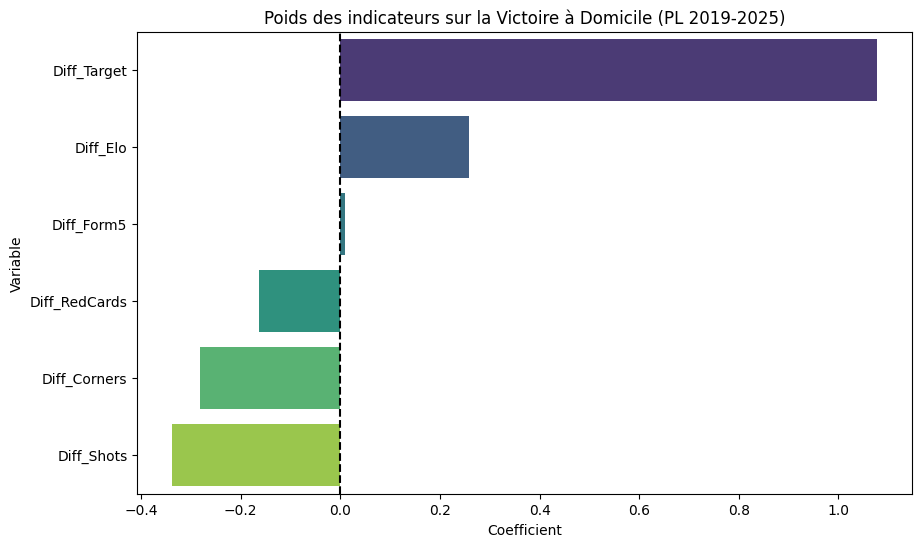

In [27]:
# Sauvegarde du graphique
import matplotlib.pyplot as plt

# On recrée le graphique (ou on utilise le dernier généré)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', data=importance_df, palette='viridis')
plt.title('Poids des indicateurs sur la Victoire à Domicile (PL 2019-2025)')
plt.axvline(0, color='black', linestyle='--')

# Sauvegarde en fichier PNG
plt.savefig('../output/coefficients_chart.png', dpi=300, bbox_inches='tight')
print("Le fichier 'coefficients_chart.png' a été généré dans le dossier Colab.")

In [28]:
# Sauvegarde du résumé statistique
# On convertit le résumé en texte
summary_text = result.summary(xname=['Intercept'] + X_cols).as_text()

# On l'écrit dans un fichier .txt
with open("../output/model_summary.txt", "w") as f:
    f.write(summary_text)

print("Le fichier 'model_summary.txt' a été généré avec succès.")

Le fichier 'model_summary.txt' a été généré avec succès.
